# Kenya Climate Data Analysis (2015–2026)

## Objective
This notebook analyzes climate data to identify trends and patterns.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading

The dataset is loaded from a local CSV file. A new column is added to indicate the country for easier identification during analysis.

In [2]:
df = pd.read_csv("../data/kenya.csv")
df["Country"] = "Kenya"

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya


## Date Conversion

The dataset provides YEAR and DOY (Day of Year). These are combined to create a proper datetime column, which is necessary for time series analysis. A Month column is also extracted for seasonal analysis.

In [3]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df[["YEAR", "DOY", "Date", "Month"]].head()

,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


## Handling Missing Values

The dataset may contain -999 values, which represent missing or invalid data from the source. These are replaced with NaN to avoid distortion in statistical analysis.

In [4]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3


## Duplicate Records

We check for duplicate rows in the dataset to ensure data integrity.

In [5]:
duplicates = df.duplicated().sum()
duplicates

df.drop_duplicates(inplace=True)


duplicate rows were detected and removed.

## Summary Statistics

Basic descriptive statistics are computed to understand the distribution of climate variables such as temperature, precipitation, and humidity.

In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


### Interpretation

- The mean temperature (T2M) indicates generally mild to warm conditions.
- The maximum temperature (T2M_MAX) shows occasional high-temperature extremes, which may indicate heat stress periods.
- Precipitation (PRECTOTCORR) appears highly variable, suggesting seasonal rainfall patterns.
- Relative humidity (RH2M) values suggest moderate atmospheric moisture levels.

## Missing Value Analysis

We evaluate the number and percentage of missing values in each column to assess data quality.

In [7]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_percent
})

,Missing Values,Percentage (%)
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


Columns with more than 5% missing values may require careful handling, such as imputation or exclusion, depending on their importance to the analysis. We have no missing values here.

## Outlier Detection

Z-scores are used to identify extreme values in selected climate variables. Observations with absolute Z-score greater than 3 are considered potential outliers.

In [8]:
import scipy
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
outliers

T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64

### Outlier Analysis Interpretation

Outlier detection indicates that precipitation has the highest number of extreme values, reflecting significant variability and the occurrence of intense rainfall events.

Other variables show relatively few outliers, suggesting more stable behavior.

These outliers are retained as they likely represent real climatic extremes rather than data errors.

## Handling Missing Values

Missing values are handled using forward-fill for continuous weather variables. Rows with excessive missing data may be dropped to maintain data quality.

In [9]:
##df.fillna(method='ffill', inplace=True)
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3


Forward-fill is applied to preserve temporal continuity in the dataset. This approach assumes that short gaps in measurements can be approximated using previous observations.

Rows with excessive missing values are removed to avoid unreliable analysis.

In [10]:
df.to_csv("../data/kenya_clean.csv", index=False)

The cleaned dataset is saved for further analysis and cross-country comparison.

## Temperature Trend Analysis

We analyze monthly average temperature (T2M) over time to identify long-term trends and seasonal patterns.

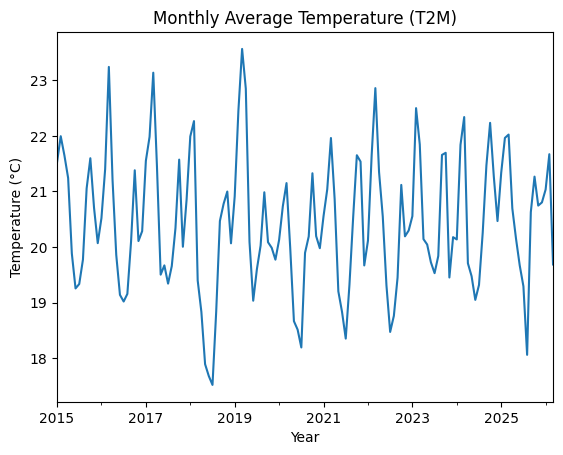

In [11]:
# Create a time-indexed DataFrame
df_time = df.set_index("Date")

# Monthly average temperature
monthly_temp = df_time["T2M"].resample("ME").mean()

# Plot
plt.figure()
monthly_temp.plot()
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

### Temperature Trend Interpretation

The temperature trend shows consistent seasonal fluctuations across the years, with regular peaks and troughs indicating a stable annual cycle.

Temperatures generally remain within a narrow range, suggesting a relatively stable climate without significant long-term warming or cooling trends.

This stability indicates predictable temperature conditions, which are important for agriculture and environmental planning.

## Seasonal Temperature Pattern

To better understand seasonal behavior, we examine the average temperature for each month across all years.

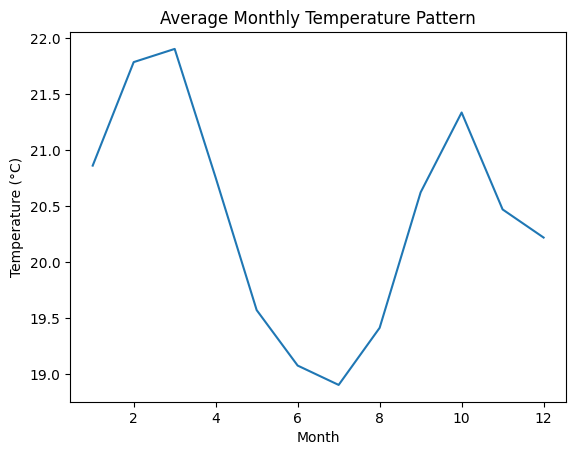

In [12]:
monthly_temp_pattern = df.groupby("Month")["T2M"].mean()

plt.figure()
monthly_temp_pattern.plot()
plt.title("Average Monthly Temperature Pattern")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### Seasonal Temperature Pattern Interpretation

The seasonal temperature pattern shows a clear annual cycle, with temperatures peaking in the early months of the year and declining منتصف the year before rising again slightly.

This suggests a bimodal temperature pattern, likely influenced by regional climate dynamics.

Such variation indicates that Kenya experiences multiple warm periods rather than a single dominant peak, reflecting more complex seasonal behavior.

## Precipitation Analysis

We examine monthly total precipitation to identify rainfall patterns and seasonal peaks.

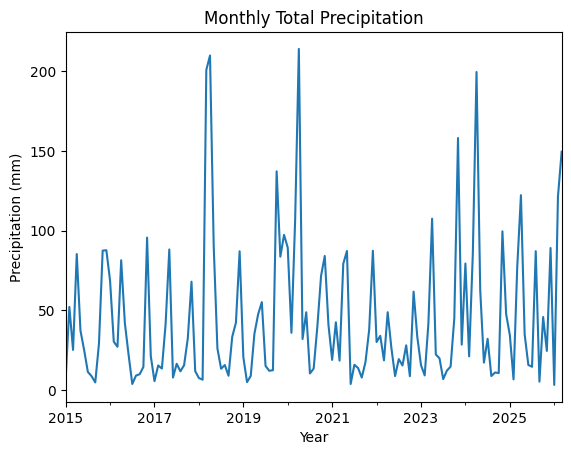

In [13]:
monthly_rain = df_time["PRECTOTCORR"].resample("ME").sum()

plt.figure()
monthly_rain.plot()
plt.title("Monthly Total Precipitation")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm)")
plt.show()

### Precipitation Trend Interpretation

The rainfall trend shows significant variability, with sharp spikes representing periods of intense rainfall followed by extended dry periods.

This irregular distribution indicates that precipitation is not evenly spread throughout the year, with sudden high-intensity events.

Such variability increases exposure to both flooding and drought risks.

## Seasonal Precipitation Pattern

We examine the average precipitation for each month to better understand the timing and concentration of rainy seasons.

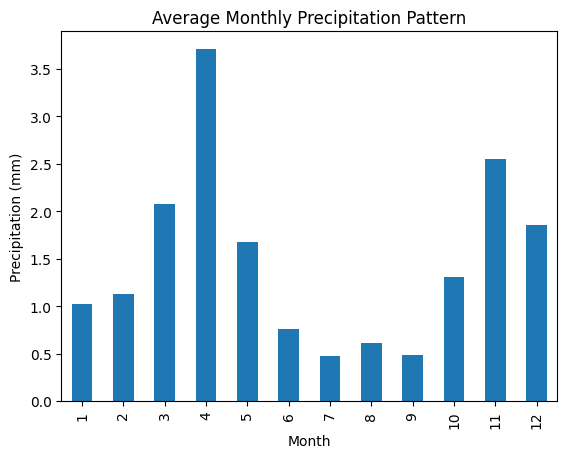

In [14]:
monthly_rain_pattern = df.groupby("Month")["PRECTOTCORR"].mean()

plt.figure()
monthly_rain_pattern.plot(kind="bar")
plt.title("Average Monthly Precipitation Pattern")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.show()

### Seasonal Precipitation Pattern Interpretation

The precipitation pattern reveals a bimodal rainfall distribution, with two distinct peaks occurring around April–May and November–December.

This indicates the presence of two rainy seasons, separated by relatively drier periods.

Such a pattern is characteristic of regions influenced by shifting weather systems, and it plays a crucial role in agricultural cycles and water resource planning.

## Correlation Analysis

We examine relationships between key climate variables using a correlation matrix. This helps identify how different environmental factors interact with each other.

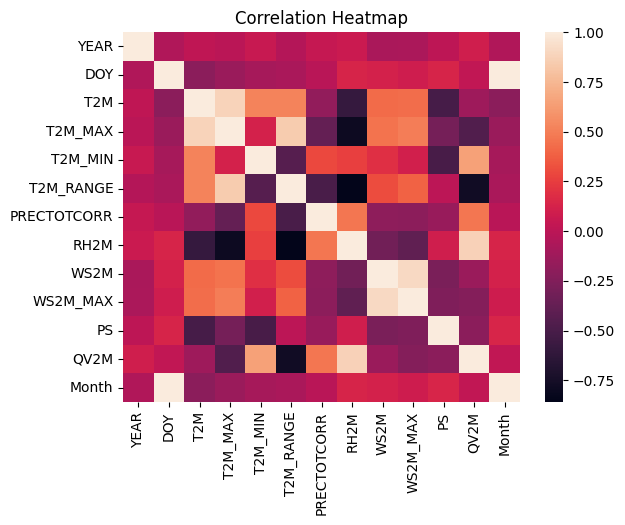

In [15]:
corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=False)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap Interpretation

The heatmap shows strong positive correlations among temperature variables, indicating consistency in temperature measurements.

Precipitation has a positive relationship with relative humidity, reinforcing the role of atmospheric moisture in rainfall formation.

Temperature tends to have weak or negative relationships with precipitation and humidity, suggesting that rainfall is influenced by multiple interacting factors.

Wind-related variables exhibit weak correlations, indicating a limited direct impact on temperature and precipitation patterns.

## Variable Relationships

Scatter plots are used to further explore relationships between key variables identified in the correlation analysis.

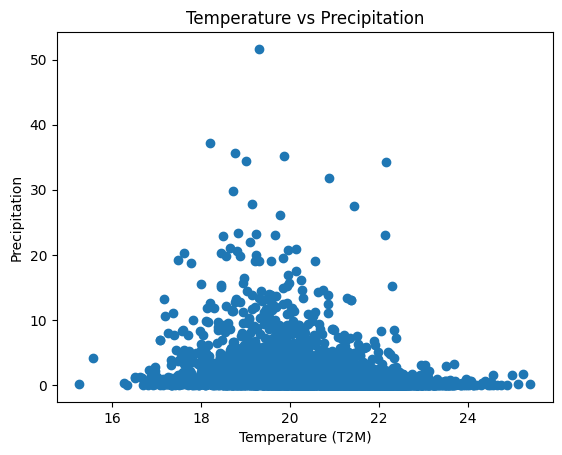

In [16]:
plt.figure()
plt.scatter(df["T2M"], df["PRECTOTCORR"])
plt.xlabel("Temperature (T2M)")
plt.ylabel("Precipitation")
plt.title("Temperature vs Precipitation")
plt.show()

### Temperature vs Precipitation Interpretation

The relationship between temperature and precipitation is weak and non-linear.

Most rainfall occurs within a moderate temperature range, while extreme temperatures show little association with precipitation.

This suggests that temperature alone is not a strong predictor of rainfall, and other factors such as humidity play a more significant role.

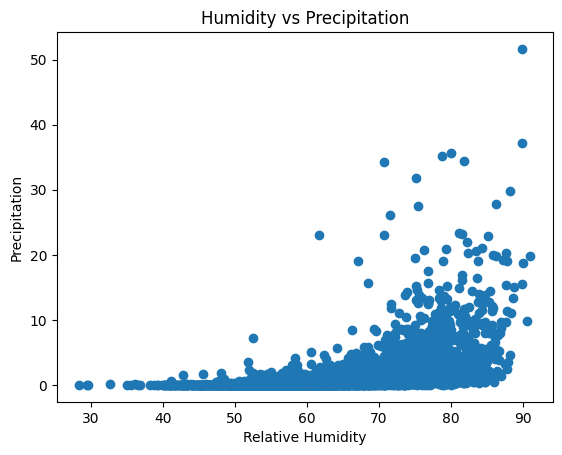

In [17]:
plt.figure()
plt.scatter(df["RH2M"], df["PRECTOTCORR"])
plt.xlabel("Relative Humidity")
plt.ylabel("Precipitation")
plt.title("Humidity vs Precipitation")
plt.show()

### Humidity vs Precipitation Interpretation

The scatter plot shows a strong positive relationship between humidity and precipitation.

Rainfall events occur primarily at higher humidity levels, while low humidity conditions are associated with little to no precipitation.

This confirms that atmospheric moisture is a key driver of rainfall in the region.

## Key Insights

- Kenya exhibits a bimodal climate pattern, with two distinct rainy seasons occurring خلال the year.
- Temperature remains relatively stable, with predictable seasonal fluctuations and no strong long-term trend.
- Rainfall is highly variable, with intense precipitation events separated by dry periods.
- Precipitation is strongly influenced by humidity, highlighting the importance of atmospheric moisture.
- Temperature shows limited direct influence on rainfall, indicating that precipitation depends on multiple interacting factors.
- The presence of extreme rainfall events suggests potential vulnerability to flooding, while dry periods indicate risk of drought.

These findings highlight the complexity of Kenya’s climate system and provide a basis for comparison with other countries.